In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller 
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [27]:
data = {
    'Date':pd.date_range('2025-01-01', periods=36, freq='ME'),
    'Sales':[
        100,112,121,133,141,152,
        160,171,182,171,161,149,

        118,131,142,151,163,174,
        182,194,203,191,183,171,

        141,152,163,174,185,193,
        202,214,223,212,201,191
    ]
}

df = pd.DataFrame(data)
df.set_index(df['Date'], inplace=True)
df.head()

,Date,Sales
Date,,
2025-01-31,2025-01-31,100
2025-02-28,2025-02-28,112
2025-03-31,2025-03-31,121
2025-04-30,2025-04-30,133
2025-05-31,2025-05-31,141


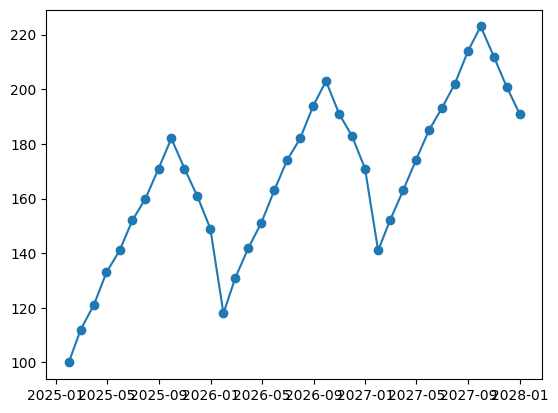

In [28]:
plt.plot(df['Sales'],marker='o')
plt.show()

In [29]:
results = adfuller(df['Sales'])

print('ADF Stats:',results[0])
print('p-value',results[1])


ADF Stats: 0.2700430757505503
p-value 0.9759275550942403


In [30]:
df['Sales_diff'] = df['Sales'].diff()
df_diff = df['Sales_diff'].dropna()

results = adfuller(df_diff)

print('ADF Stats:',results[0])
print('p-value',results[1])

ADF Stats: -23.73674572440207
p-value 0.0


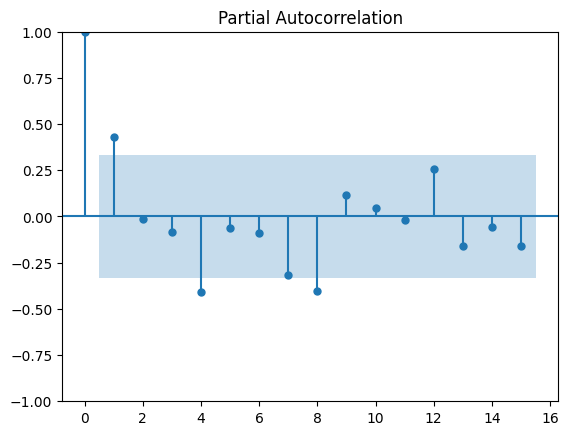

In [31]:
#plot pacf (p)

plot_pacf(df_diff,lags=15)
plt.show()

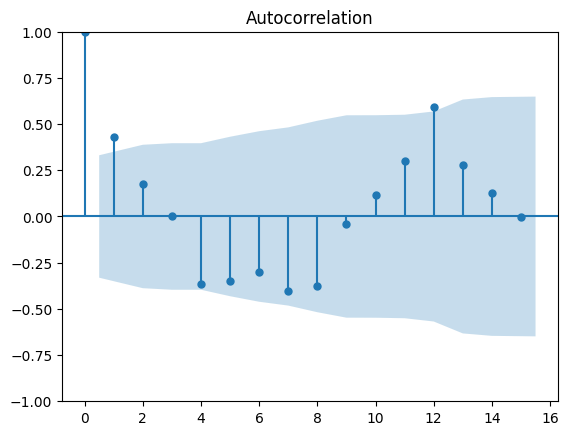

In [32]:
#plot acf

plot_acf(df_diff,lags=15)
plt.show()

p=1,q=1,d=1

In [33]:
#Seasonal Diff

df['Seasonal_diff'] = df['Sales'].diff(12)
seasonal_diff = df['Seasonal_diff'].dropna()

In [34]:
results = adfuller(seasonal_diff)

print('ADF Stats:',results[0])
print('p-value',results[1])

ADF Stats: -3.731091856160216
p-value 0.003696476814684254


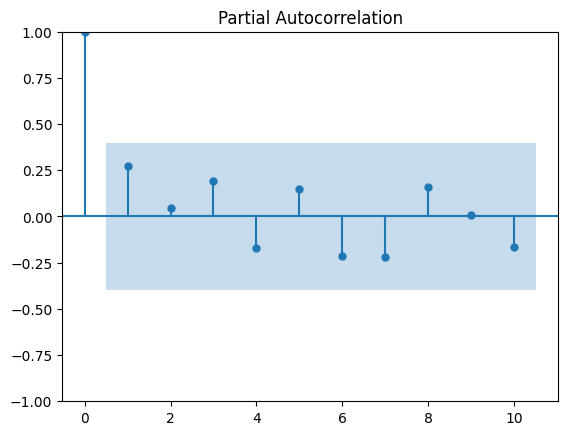

In [35]:
#choose p

plot_pacf(seasonal_diff,lags=10)
plt.show()

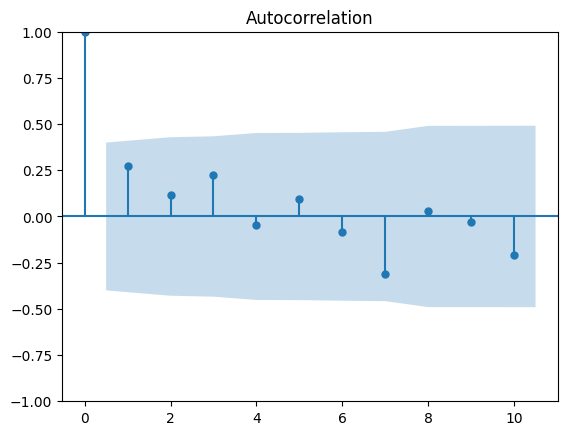

In [36]:
plot_acf(seasonal_diff,lags=10)
plt.show()

P=1,Q=1,m=12

In [37]:
train = df.iloc[:30]
test = df.iloc[30:]

In [38]:
model = SARIMAX(
    train['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [39]:
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [40]:
forecast = model_fit.forecast(steps=(len(test)))

print(forecast)

2027-07-31    202.415632
2027-08-31    213.670436
2027-09-30    223.851841
2027-10-31    212.430671
2027-11-30    203.270005
2027-12-31    191.257271
Freq: ME, Name: predicted_mean, dtype: float64


In [41]:
mae = mean_absolute_error(test['Sales'],forecast)

rmse = np.sqrt(mean_squared_error(test['Sales'],forecast))

print(mae)
print(rmse)

0.7591638783745509
1.0337299297146012


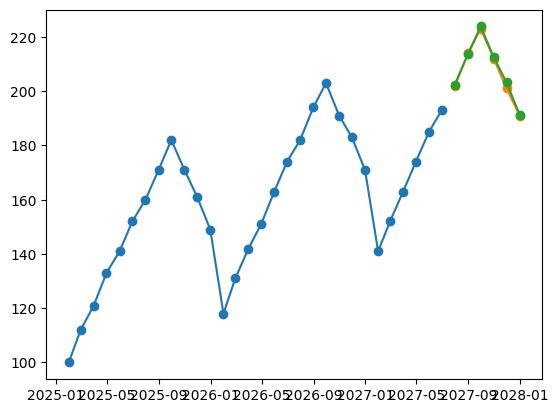

In [42]:
plt.plot(train.index, train['Sales'],marker='o',label='Train')
plt.plot(test.index, test['Sales'], marker='o', label='Actual')
plt.plot(test.index, forecast, marker='o', label='Predicted')

plt.show()

In [43]:
model = SARIMAX(df['Sales'],order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [44]:
future_forecast = model_fit.forecast(steps=6)
print(future_forecast)

2028-01-31    159.467944
2028-02-29    171.754033
2028-03-31    183.475266
2028-04-30    192.563473
2028-05-31    205.447687
2028-06-30    214.652260
Freq: ME, Name: predicted_mean, dtype: float64


In [45]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthEnd(),
    periods=6,
    freq='ME'
)

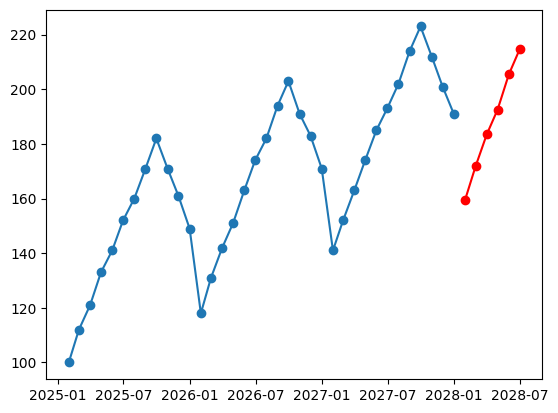

In [46]:
plt.plot(df.index, df['Sales'], marker='o')
plt.plot(future_dates,future_forecast,marker='o',color='red',label='Future Forecast')
plt.show()